In [1]:
# Import mosaic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from collections import defaultdict
import matplotlib.patches as patches
import matplotlib.patches as mpatches
from matplotlib import cm
from matplotlib.patches import Patch


In [2]:
def annotate_spliceai_effect(df: pd.DataFrame) -> pd.DataFrame:
    cols = ['SpliceAI_pred_DS_AG','SpliceAI_pred_DS_AL','SpliceAI_pred_DS_DG','SpliceAI_pred_DS_DL']
    labels = ['acceptor_gain', 'acceptor_loss','donor_gain','donor_loss']
    ds_matrix = (df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy())
    max_idx = ds_matrix.argmax(axis=1)
    max_score = ds_matrix.max(axis=1)
    severity = np.select(
        [max_score >= 0.8,max_score >= 0.5,max_score >= 0.2],
        ['high','moderate','low'],
        default='none'
    )
    # Map effect
    effect = [labels[i] for i in max_idx]
    effect = np.where(max_score == 0, 'none', effect)
    df['spliceai_severity'] = severity
    df['spliceai_effect'] = effect

    return df

def categorize_hc_lof(row) -> str:
    lof_flag = str(row.get("LoF", "")).upper()
    spliceai_sev = str(row.get("spliceai_severity", "")).lower()
    if lof_flag in {"HC", "OS"} or spliceai_sev == "high":
        return "Yes"
    return np.nan

output_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data"

LOF = {
    "stop_gained", "frameshift_variant", "stop_gained&frameshift_variant",
    "splice_acceptor_variant", "splice_donor_variant",
    "stop_gained&splice_region_variant", "frameshift_variant&splice_region_variant"
}

indel_terms = [
    "frameshift_variant",
    "frameshift_variant&splice_region_variant",
    "stop_gained&frameshift_variant",
    "stop_gained&inframe_deletion",
    "inframe_deletion",
    "inframe_insertion",
    "frameshift_variant&stop_lost",
    "frameshift_variant&start_lost",
]

non_coding_terms = [
    "intron_variant",
    "splice_polypyrimidine_tract_variant&intron_variant",
    "splice_region_variant&splice_polypyrimidine_tract_variant&intron_variant",
    "splice_donor_region_variant&intron_variant",
    "splice_region_variant&5_prime_UTR_variant",
    "splice_donor_5th_base_variant&intron_variant",
    "splice_region_variant&intron_variant",
    "3_prime_UTR_variant",
    "5_prime_UTR_variant"
]

splice_site_terms = ["splice_acceptor_variant", "splice_donor_variant"]
missense_terms = ["missense_variant", "missense_variant&splice_region_variant"]
nonsense_terms = ["stop_gained", "stop_gained&splice_region_variant", "stop_gained&frameshift_variant", "stop_gained&inframe_deletion"]
frameshift_terms = ["frameshift_variant", "frameshift_variant&splice_region_variant", "frameshift_variant&stop_lost", "frameshift_variant&start_lost"]
synonymous_terms = ['synonymous_variant', 'stop_retained_variant', 'splice_region_variant&synonymous_variant']
nonsynonymous_terms = [
    "start_lost",
    "missense_variant",
    "frameshift_variant",
    "stop_gained",
    "missense_variant&splice_region_variant",
    "inframe_deletion",
    "frameshift_variant&splice_region_variant",
    "inframe_insertion",
    "stop_gained&splice_region_variant",
    "stop_lost",
    "stop_gained&frameshift_variant",
    "frameshift_variant&stop_lost",
    "stop_gained&inframe_deletion",
    "frameshift_variant&start_lost",
]

parquet_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/"
AF_FILTERED = pd.read_parquet(f"{parquet_dir}AF_filtered_STG_final.parquet")
DP = pd.read_parquet(f"{parquet_dir}DP_filtered_STG_final.parquet")
metadata_filtered = pd.read_parquet(f"{parquet_dir}metadata_filtered_repeats_germline_freq.parquet")
GQ = pd.read_parquet(f"{parquet_dir}GQ_filtered_STG_final.parquet")
NGT_final = pd.read_parquet(f"{parquet_dir}NGT_filtered_STG_final.parquet")

metadata_filtered['age_at_death'] = metadata_filtered['age_at_death'].astype(str).str.replace(',', '.', regex=False)
metadata_filtered = metadata_filtered.loc[NGT_final.index]

# Load annotations
annotations = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/Annotations_STG.csv', sep='\t', header=0) 
annotations['Protein_annotation'] = annotations['HGVSp'].str.split(".", expand=True)[2]

annotations = annotations[annotations['variant_id'].isin(NGT_final.columns)]
annotate_spliceai_effect(annotations)

genes = ["TARDBP", "TET2", "TMEM106B", "OPTN", "TBK1", "GRN", "UNC13A"]

annotations_df = []
NGT_list_filtered = []
NGT_patients_list = []
NGT_controls_list = []

ann_all_vars_list = []
ann_all_snv_list = []
ann_all_indels_list = []

ann_coding_list = []
ann_indels_list = []
ann_snv_list = []

ann_nonsyn_list = []
ann_syn_list = []
ann_missense_list = []
ann_nonsense_list = []
ann_frameshift_list = []
ann_splicesite_list = []
ann_startloss_list = []
ann_stoploss_list = []
cadd_above20_list = []
ann_LOF_list = []
ann_HC_LOF_list = []


var_groups_dict = {}
burden_dict = {}
var_groups_names = [
    "Coding_variants", "SNVs", "Indels", "Synonymous",
    "Non_synonymous", "Missense", "Nonsense",
    "Frameshift", "Splice site", "LOF", "HC_LOF", "CADD_atleast20",
]

for i, gene_name in enumerate(genes):
    ann = annotations[annotations['SYMBOL']==gene_name].copy()
    ann.index = ann['variant_id']
    ann["HC_LOF"] = ann.apply(categorize_hc_lof,  axis=1)
    ann = ann.set_index('variant_id')

    vars = ann.index.tolist()
    NGT = NGT_final.loc[:, vars].copy()
    #print("Number of variants per bp covered:", np.round(NGT.shape[1]/genes_bp[i], 3))
    meta = metadata_filtered.reindex(NGT.index).copy()

    NGT = NGT.assign(
        sample_identifier = meta['ID'],
        sample_id         = meta['sample_id'],
        sample_type       = meta['sample_type'],
        age_at_death      = meta['age_at_death'].to_numpy(),
        age_at_onset      = meta['age_at_onset'].to_numpy(),
        hemisphere        = meta['hemisphere'],
    )
    NGT_list_filtered.append(NGT)
    
    NGT_controls = NGT[NGT['sample_type'] == "C"]
    NGT_patients = NGT[NGT['sample_type'] == "P"]

    counts = pd.DataFrame({
        "cell_count_patients": NGT_patients.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_P": NGT_patients.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts["mutation_freq_P"] = counts["cell_count_patients"] / counts["total_genotyped_cells_P"] * 100
    ann = ann.merge(counts, left_index=True, right_index=True, how="inner")

    counts_C = pd.DataFrame({
        "cell_count_controls": NGT_controls.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_C": NGT_controls.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts_C["mutation_freq_C"] = counts_C["cell_count_controls"] / counts_C["total_genotyped_cells_C"] * 100
    ann = ann.merge(counts_C, left_index=True, right_index=True, how="inner")
    ann["total_cells"] = ann["cell_count_patients"] + ann["cell_count_controls"]
    ann["total_genotyped_cells"] = ann['total_genotyped_cells_P'] + ann['total_genotyped_cells_C']
    ann['total_freq'] = ann["total_cells"]/ann['total_genotyped_cells']*100

    annotations_df.append(ann)
    NGT_patients_list.append(NGT_patients)
    NGT_controls_list.append(NGT_controls)

    lengths_ref = ann['REF'].apply(len)
    length_alt = ann['ALT'].apply(len)
    indels = (lengths_ref[lengths_ref >1].index.to_list()) + (length_alt[length_alt >1].index.to_list()) 
    indels = list(set(indels))
    ann_all_snv = ann.drop(index = indels) 
    ann_all_indels = ann.loc[indels]

    ann_coding = ann[~ann['Consequence'].isin(non_coding_terms)]
    ann_indel = ann_coding[ann_coding['Consequence'].isin(indel_terms)] #Indels in coding regions 
    ann_snv = ann_coding[~ann_coding['Consequence'].isin(indel_terms)] # SNVs in coding regions
    
    ann_nonsyn = ann_coding[ann_coding['Consequence'].isin(nonsynonymous_terms)]
    ann_syn = ann_coding[ann_coding['Consequence'].isin(synonymous_terms)]
    ann_missense = ann_coding[ann_coding['Consequence'].isin(missense_terms)]
    ann_nonsense = ann_coding[ann_coding['Consequence'].isin(nonsense_terms)]
    ann_frameshift = ann_coding[ann_coding['Consequence'].isin(frameshift_terms)]
    ann_splicesite = ann_coding[ann_coding['Consequence'].isin(splice_site_terms)]
    ann_startloss = ann_coding[ann_coding['Consequence'].isin(["start_lost"])]
    ann_stoploss = ann_coding[ann_coding['Consequence'].isin(["stop_lost"])]
    ann_lof = ann_coding[ann_coding['Consequence'].isin(list(LOF))]
    ann_lof_hf = ann_lof[ann_lof['HC_LOF']=="Yes"]
    cadd_above20 = ann_snv[ann_snv['CADD_PHRED'] >= 20]

    ann_all_vars_list.append(ann)
    ann_all_snv_list.append(ann_all_snv)
    ann_all_indels_list.append(ann_all_indels)
    ann_snv_list.append(ann_snv)
    ann_indels_list.append(ann_indel)
    ann_coding_list.append(ann_coding)
    ann_nonsyn_list.append(ann_nonsyn)
    ann_syn_list.append(ann_syn)

    ann_missense_list.append(ann_missense)
    ann_nonsense_list.append(ann_nonsense)
    ann_frameshift_list.append(ann_frameshift)
    ann_splicesite_list.append(ann_splicesite)
    ann_startloss_list.append(ann_startloss)
    ann_stoploss_list.append(ann_stoploss)
    ann_LOF_list.append(ann_lof)
    ann_HC_LOF_list.append(ann_lof_hf)
    cadd_above20_list.append(cadd_above20)

    var_groups_dict[gene_name] = {
        group_name: group_list[i]
        for group_name, group_list in zip(
            var_groups_names,
            [
                ann_coding_list,
                ann_snv_list,
                ann_indels_list,
                ann_syn_list,
                ann_nonsyn_list,
                ann_missense_list,
                ann_nonsense_list,
                ann_frameshift_list,
                ann_splicesite_list,
                ann_LOF_list,
                ann_HC_LOF_list,
                cadd_above20_list

            ]
        )
    }

    df = NGT.copy()
    ids_selected = df['sample_id'].unique()
    list_vars = var_groups_dict[gene_name]
    

/tmp/ipykernel_379440/2870584869.py:91: DtypeWarning: Columns (37,39,76) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/Annotations_STG.csv', sep='\t', header=0)


In [3]:
#Print number of variants in each group
for gene, groups in var_groups_dict.items():
    print(gene)
    
    for group_name, variants in groups.items():
        print(f"{group_name} : {len(variants)}")
    
    print("")

TARDBP
Coding_variants : 1503
SNVs : 1451
Indels : 52
Synonymous : 411
Non_synonymous : 1079
Missense : 964
Nonsense : 58
Frameshift : 51
Splice site : 13
LOF : 122
HC_LOF : 122
CADD_atleast20 : 906

TET2
Coding_variants : 4965
SNVs : 4763
Indels : 202
Synonymous : 1447
Non_synonymous : 3485
Missense : 3093
Nonsense : 188
Frameshift : 192
Splice site : 33
LOF : 412
HC_LOF : 369
CADD_atleast20 : 1660

TMEM106B
Coding_variants : 1042
SNVs : 1017
Indels : 25
Synonymous : 296
Non_synonymous : 714
Missense : 650
Nonsense : 37
Frameshift : 24
Splice site : 32
LOF : 92
HC_LOF : 92
CADD_atleast20 : 619

OPTN
Coding_variants : 2027
SNVs : 1942
Indels : 85
Synonymous : 566
Non_synonymous : 1424
Missense : 1259
Nonsense : 78
Frameshift : 80
Splice site : 37
LOF : 195
HC_LOF : 195
CADD_atleast20 : 886

TBK1
Coding_variants : 2491
SNVs : 2397
Indels : 94
Synonymous : 683
Non_synonymous : 1748
Missense : 1566
Nonsense : 82
Frameshift : 93
Splice site : 60
LOF : 235
HC_LOF : 235
CADD_atleast20 : 1476

Analysing TARDBP variants

In [4]:
NGT = NGT_list_filtered[0].copy()
ann= var_groups_dict["TARDBP"]['Coding_variants'].copy()
ann['Protein_position'] = pd.to_numeric(ann['Protein_position'], errors='coerce').astype('Int64')

In [5]:
for category in ['Coding_variants', 'Non_synonymous']:
    df = var_groups_dict["TARDBP"][category].copy()
    df['Protein_position'] = pd.to_numeric(df['Protein_position'], errors='coerce').astype('Int64')
    print(f"Number of CTD {category}: {df[df['Protein_position']>= 274].shape[0]}") 


Number of CTD Coding_variants: 419
Number of CTD Non_synonymous: 300


In [6]:
ann= var_groups_dict["TARDBP"]['Coding_variants'].copy()
ann_clean = ann[~ann['Protein_position'].str.contains('-', na=False)]
ann_clean = ann_clean.copy()
ann_clean['CDS_position'] = pd.to_numeric(ann_clean['CDS_position'], errors='coerce')
ann_clean['Protein_position'] = pd.to_numeric(ann_clean['Protein_position'], errors='coerce')


In [7]:
#For which codons no variant is detected? 
expected = list(range(1,66)) + list(range(80,246+1)) + list(range(264,292+1)) + list(range(296,339+1)) + list(range(352,414+1))
actual = ann_clean['Protein_position']  
missing = sorted(set(expected) - set(actual))
print("Codons no vars:", missing)

Codons no vars: [21, 22, 138, 139, 289, 290, 291, 292]


### Check frequencies for known TARDBP (germline) mutations

In [8]:
alsod_vars  = ['A315A','A315E','A315T','A321G','A321V','A366A','A382P',
'A382T','A66A','A90V','D169G','D65E','G287S','G290A','G294A','G294V','G295C','G295R',
'G295S','G298S','G335D','G348C','G348V','G357R','G357S','G368S','G376D','G384R','G40G','I383T',
'I383V','M311V','M337V','M359V','N267S','N345K','N352N','N352S','N352T','N378D','N378S',
'N390D','N390S','P225P','P363A','Q303H','Q331K','Q343R','R361S','R361T','S104S','S292N',
'S317T','S332N','S375G','S379C','S379P','S393L','W385G','Y374*']
alsod_vars = sorted(alsod_vars, key=lambda x: int(re.search(r'\d+', x).group()))

In [9]:
# Drop the variants that could not de detected as they were not targeted, and also the synonymous variants 
known_ALS_mutations = [x for x in alsod_vars if x not in ['Q343R', 'N345K', 'G348C', 'G348V','G40G', 'A66A']]
len(known_ALS_mutations)

54

In [10]:
def make_protein_annot(protein_position, amino_acids):
    if pd.isna(protein_position) or pd.isna(amino_acids):
        return np.nan
    pp = str(protein_position).strip()
    aa = str(amino_acids).strip()
    if "/" in aa:
        ref, alt = aa.split("/")[:2]
        ref, alt = ref.strip(), alt.strip()
        if ref and alt and pp:
            return f"{ref}{pp}{alt}"
        return np.nan
    if re.fullmatch(r"\d+\-\d+", pp) and re.fullmatch(r"[A-Za-z\*]+", aa):
        return f"{aa}{pp}*"
    return np.nan

ann['Protein_position'] = (
    ann['Protein_position']
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
)

ann['Protein_annotation_singleaa'] = ann.apply(
    lambda r: make_protein_annot(
        r["Protein_position"],
        r["Amino_acids"]  
    ),
    axis=1
)

In [11]:
df = ann[ann['Protein_annotation_singleaa'].isin(known_ALS_mutations)]
# Variants detected in only patients 
patient_specific_als_vars = df[df['cell_count_controls']==0].index.to_list()
cols = [c for c in patient_specific_als_vars if c in NGT.columns]
cols += ['sample_id', 'sample_type']
dd = NGT[cols].copy()

results = []
freqs = []
for col in dd.columns:
    mask = dd[col].isin([1, 2])
    n_rows = mask.sum()
    patients_affected = dd.loc[mask, 'sample_id']
    for sample in patients_affected:
            dd_sample = dd[dd['sample_id']==sample]
            mask = dd_sample[col].isin([1, 2])
            carriers = mask.sum()
            mask2 = dd_sample[col].isin([0,1, 2])
            total_cells_genotyped = mask2.sum()
            freq = np.round((carriers/total_cells_genotyped)*100, 3)
            freqs.append(freq)
            print(f"Variant {(ann.loc[col]['Protein_annotation_singleaa'])}, Sample {sample},freq {freq} [{carriers}/{total_cells_genotyped}]")
    results.append({'variant_id': col, 'n_cells': n_rows, 'samples affected': patients_affected.nunique(), 'samples': patients_affected.unique() })

summary_df = pd.DataFrame(results)
summary_df.set_index('variant_id', inplace=True)

Variant N267S, Sample I3_P,freq 0.053 [1/1904]
Variant N267S, Sample J3_P,freq 0.141 [2/1423]
Variant N267S, Sample J3_P,freq 0.141 [2/1423]
Variant N267S, Sample N2_P,freq 0.249 [2/803]
Variant N267S, Sample N2_P,freq 0.249 [2/803]
Variant N267S, Sample O1_P,freq 0.029 [1/3445]
Variant N267S, Sample Q3_P,freq 0.132 [1/760]
Variant N267S, Sample C3_P,freq 0.042 [1/2361]
Variant G298S, Sample N2_P,freq 0.124 [1/804]
Variant G298S, Sample E4_P,freq 0.024 [1/4144]
Variant Q303H, Sample G4_P,freq 0.06 [1/1674]
Variant Q303H, Sample G5_P,freq 0.048 [1/2070]
Variant Q303H, Sample E4_P,freq 0.024 [1/4128]
Variant M311V, Sample J3_P,freq 0.07 [1/1425]
Variant M311V, Sample C3_P,freq 0.042 [1/2357]
Variant M311V, Sample C5_P,freq 0.113 [1/883]
Variant M311V, Sample E3_P,freq 0.787 [1/127]
Variant M311V, Sample F5_P,freq 0.177 [1/565]
Variant A315T, Sample O1_P,freq 0.029 [1/3445]
Variant G335D, Sample N2_P,freq 0.125 [1/802]
Variant G335D, Sample F3_P,freq 0.261 [1/383]
Variant M337V, Sample Q3

In [12]:
results = []
freqs = []
for col in dd.columns:
    mask = dd[col].isin([1, 2])
    n_rows = mask.sum()
    patients_affected = dd.loc[mask, 'sample_id']
    for sample in patients_affected:
            dd_sample = dd[dd['sample_id']==sample]
            mask = dd_sample[col].isin([1, 2])
            carriers = mask.sum()
            mask2 = dd_sample[col].isin([0,1, 2])
            total_cells_genotyped = mask2.sum()
            freq = np.round((carriers/total_cells_genotyped)*100, 3)
            freqs.append(freq)
            print(f" Sample {sample},freq {freq} [{carriers}/{total_cells_genotyped}]")
    results.append({'variant_id': col, 'n_cells': n_rows, 'samples affected': patients_affected.nunique(), 'samples': patients_affected.unique() })


 Sample I3_P,freq 0.053 [1/1904]
 Sample J3_P,freq 0.141 [2/1423]
 Sample J3_P,freq 0.141 [2/1423]
 Sample N2_P,freq 0.249 [2/803]
 Sample N2_P,freq 0.249 [2/803]
 Sample O1_P,freq 0.029 [1/3445]
 Sample Q3_P,freq 0.132 [1/760]
 Sample C3_P,freq 0.042 [1/2361]
 Sample N2_P,freq 0.124 [1/804]
 Sample E4_P,freq 0.024 [1/4144]
 Sample G4_P,freq 0.06 [1/1674]
 Sample G5_P,freq 0.048 [1/2070]
 Sample E4_P,freq 0.024 [1/4128]
 Sample J3_P,freq 0.07 [1/1425]
 Sample C3_P,freq 0.042 [1/2357]
 Sample C5_P,freq 0.113 [1/883]
 Sample E3_P,freq 0.787 [1/127]
 Sample F5_P,freq 0.177 [1/565]
 Sample O1_P,freq 0.029 [1/3445]
 Sample N2_P,freq 0.125 [1/802]
 Sample F3_P,freq 0.261 [1/383]
 Sample Q3_P,freq 0.131 [1/761]
 Sample E4_P,freq 0.073 [3/4100]
 Sample E4_P,freq 0.073 [3/4100]
 Sample E4_P,freq 0.073 [3/4100]
 Sample F5_P,freq 0.177 [1/564]
 Sample E4_P,freq 0.024 [1/4148]
 Sample Q3_P,freq 0.131 [1/761]
 Sample T4_P,freq 0.099 [1/1007]
 Sample B3_P,freq 0.09 [1/1117]
 Sample B5_P,freq 0.093 [

In [13]:
patient_only = df[df['cell_count_controls']==0]
patient_only = patient_only.merge(summary_df, left_index=True, right_index=True, how='left') 
patient_only[['Protein_annotation', 'Protein_annotation_singleaa', 'cell_count_patients','samples affected' , 'samples', 'CADD_PHRED', 'am_pathogenicity']]

,Protein_annotation,Protein_annotation_singleaa,cell_count_patients,samples affected,samples,CADD_PHRED,am_pathogenicity
variant_id,,,,,,,
chr1:11022209:A/G,Asn267Ser,N267S,8,6,"[I3_P, J3_P, N2_P, O1_P, Q3_P, C3_P]",17.07,0.0523
chr1:11022301:G/A,Gly298Ser,G298S,2,2,"[N2_P, E4_P]",19.95,0.0724
chr1:11022318:A/T,Gln303His,Q303H,3,3,"[G4_P, G5_P, E4_P]",16.34,0.1596
chr1:11022340:A/G,Met311Val,M311V,5,5,"[J3_P, C3_P, C5_P, E3_P, F5_P]",17.01,0.0972
chr1:11022352:G/A,Ala315Thr,A315T,1,1,[O1_P],17.92,0.1854
chr1:11022413:G/A,Gly335Asp,G335D,2,2,"[N2_P, F3_P]",23.60,0.9880
chr1:11022418:A/G,Met337Val,M337V,5,3,"[Q3_P, E4_P, F5_P]",17.73,0.5729
chr1:11022536:G/A,Gly376Asp,G376D,1,1,[E4_P],23.70,0.6334
chr1:11022541:A/G,Asn378Asp,N378D,2,2,"[Q3_P, T4_P]",20.80,0.3641


In [14]:
common_patient_samples_affected = []
barcodes_all = []
patient_only_als_vars = df[df['cell_count_controls']==0].index.to_list()
for var in patient_only_als_vars:
    barcodes = NGT_patients_list[0][NGT_patients_list[0][var].isin([1, 2])].index.to_list()
    barcodes_all.extend(barcodes)
    samples_carrying_var = metadata_filtered.loc[barcodes]['sample_id'].to_list()
    print((ann.loc[var])['Protein_annotation_singleaa'], ":", list(set(samples_carrying_var)))
    common_patient_samples_affected.extend(samples_carrying_var)
print("Common patient samples affected:", len(set(common_patient_samples_affected)), set(common_patient_samples_affected))

N267S : ['I3_P', 'C3_P', 'N2_P', 'Q3_P', 'J3_P', 'O1_P']
G298S : ['E4_P', 'N2_P']
Q303H : ['E4_P', 'G4_P', 'G5_P']
M311V : ['F5_P', 'C3_P', 'C5_P', 'E3_P', 'J3_P']
A315T : ['O1_P']
G335D : ['F3_P', 'N2_P']
M337V : ['E4_P', 'F5_P', 'Q3_P']
G376D : ['E4_P']
N378D : ['T4_P', 'Q3_P']
S379P : ['B3_P']
I383T : ['D5_P', 'B5_P']
S393L : ['I3_P', 'F3_P', 'C3_P', 'G4_P', 'G5_P']
Common patient samples affected: 17 {'I3_P', 'T4_P', 'F3_P', 'F5_P', 'C3_P', 'E3_P', 'E4_P', 'C5_P', 'D5_P', 'B3_P', 'N2_P', 'Q3_P', 'B5_P', 'G4_P', 'J3_P', 'G5_P', 'O1_P'}


In [15]:
for sample in list(set(common_patient_samples_affected)):
    x = NGT_patients_list[0][NGT_patients_list[0]['sample_id'] == sample][patient_only_als_vars].isin([1,2]).sum(axis=0)
    vars_present = x[x>0].index.to_list()
    print(sample, ":", ann.loc[vars_present]['Protein_annotation_singleaa'].to_list())
    

I3_P : ['N267S', 'S393L']
T4_P : ['N378D']
F3_P : ['G335D', 'S393L']
F5_P : ['M311V', 'M337V']
C3_P : ['N267S', 'M311V', 'S393L']
E3_P : ['M311V']
E4_P : ['G298S', 'Q303H', 'M337V', 'G376D']
C5_P : ['M311V']
D5_P : ['I383T']
B3_P : ['S379P']
N2_P : ['N267S', 'G298S', 'G335D']
Q3_P : ['N267S', 'M337V', 'N378D']
B5_P : ['I383T']
G4_P : ['Q303H', 'S393L']
J3_P : ['N267S', 'M311V']
G5_P : ['Q303H', 'S393L']
O1_P : ['N267S', 'A315T']


In [16]:
# Variants detected in both patients and controls
common_als_vars = df[df['cell_count_controls']>0].index.to_list()
common_als_vars.extend(['sample_id'])
results = []
dd = NGT[common_als_vars]
freqs_both = []
for col in dd.columns[:-1]:
    mask = dd[col].isin([1, 2])
    n_cells = mask.sum()
    samples_affected = dd.loc[mask, 'sample_id']
    for sample in samples_affected:
            dd_sample = dd[dd['sample_id']==sample]
            mask = dd_sample[col].isin([1, 2])
            carriers = mask.sum()
            mask2 = dd_sample[col].isin([0,1, 2])
            total_cells_genotyped = mask2.sum()
            freq = np.round((carriers/total_cells_genotyped)*100, 3)
            freqs_both.append(freq)
            print(f"Variant {(ann.loc[col]['Protein_annotation_singleaa'])}, Sample {sample},freq{freq} [{carriers}/{total_cells_genotyped}]")
    results.append({'variant_id': col, 'n_cells': n_cells, 'samples affected': samples_affected.nunique(), 'samples': samples_affected.unique() })

summary_df = pd.DataFrame(results)
summary_df.set_index('variant_id', inplace=True)

Variant A90V, Sample M2_P,freq0.893 [1/112]
Variant A90V, Sample O1_P,freq0.064 [2/3122]
Variant A90V, Sample O1_P,freq0.064 [2/3122]
Variant A90V, Sample Q1_C,freq0.077 [1/1293]
Variant A90V, Sample C3_P,freq0.049 [1/2024]
Variant A90V, Sample F3_P,freq0.299 [1/335]
Variant D169G, Sample G4_P,freq0.119 [2/1674]
Variant D169G, Sample G4_P,freq0.119 [2/1674]
Variant D169G, Sample Q1_C,freq0.075 [1/1326]
Variant D169G, Sample B3_P,freq0.181 [2/1104]
Variant D169G, Sample B3_P,freq0.181 [2/1104]
Variant D169G, Sample B5_P,freq0.093 [1/1077]
Variant D169G, Sample E4_P,freq0.024 [1/4164]
Variant G287S, Sample N2_P,freq0.124 [1/804]
Variant G287S, Sample O1_P,freq0.029 [1/3452]
Variant G287S, Sample A2_C,freq2.941 [1/34]
Variant G287S, Sample D5_P,freq0.082 [1/1226]
Variant A321V, Sample G5_P,freq0.048 [1/2077]
Variant A321V, Sample H5_P,freq1.0 [1/100]
Variant A321V, Sample J3_P,freq0.07 [1/1426]
Variant A321V, Sample M2_P,freq0.893 [1/112]
Variant A321V, Sample Q1_C,freq0.075 [1/1331]
Vari

In [17]:
both_groups = df[df['cell_count_controls']>0]
both_groups = both_groups.merge(summary_df, left_index=True, right_index=True, how='left') 
both_groups[['Protein_annotation', 'Protein_annotation_singleaa', 'cell_count_patients','cell_count_controls','CADD_PHRED', 'am_pathogenicity']]

,Protein_annotation,Protein_annotation_singleaa,cell_count_patients,cell_count_controls,CADD_PHRED,am_pathogenicity
variant_id,,,,,,
chr1:11016874:C/T,Ala90Val,A90V,5,1,23.20,0.2919
chr1:11018836:A/G,Asp169Gly,D169G,6,1,27.90,0.9429
chr1:11022268:G/A,Gly287Ser,G287S,3,1,22.60,0.1130
chr1:11022371:C/T,Ala321Val,A321V,5,1,20.40,0.8735
chr1:11022404:G/A,Ser332Asn,S332N,3,1,18.02,0.6882
chr1:11022484:A/G,Met359Val,M359V,6,1,19.68,0.0632
chr1:11022511:G/A,Gly368Ser,G368S,4,1,23.00,0.0637
chr1:11022532:A/G,Ser375Gly,S375G,2,1,18.01,0.0619
chr1:11022542:A/G,Asn378Ser,N378S,1,1,19.80,0.0497


### Select variants that are over-represented in patients 

In [18]:
non_syn_vars = var_groups_dict['TARDBP']['Non_synonymous'].copy()
NGT= NGT_list_filtered[0]
print("Total number of non-synonymous variants in TARDBP:", non_syn_vars.shape[0])

ann = ann_nonsyn_list[0].copy()
ann['Protein_position'] = pd.to_numeric(ann['Protein_position'], errors='coerce')

Total number of non-synonymous variants in TARDBP: 1079


In [19]:
# Selecting variants which are overrepresented in a sample 
samples_with_overrep_vars = []
samples_with_no_overrep_vars = []
entries = []

#Execute for each sample 
sample_ids = NGT['sample_id'].unique().tolist()
for sample_name in sample_ids:
    NGT_sample = NGT[NGT['sample_id'] == (sample_name)]
    
    non_syn_vars["protein_change"] = (
        non_syn_vars["Amino_acids"].str.split("/")
                        .str[0]     
        + non_syn_vars["Protein_position"].astype(str)
        + non_syn_vars["Amino_acids"].str.split("/").str[1]  
    )

    NGT_sample = NGT_sample[non_syn_vars.index.tolist() + NGT_sample.columns[-6:].tolist()] # select the nonysn variants + sample info columns
    count = NGT_sample.iloc[:, :-6].isin([1, 2]).sum()
    total = NGT_sample.iloc[:, :-6].isin([0, 1, 2]).sum()
    freq = count / total

    df = pd.DataFrame({
        'n_cells_mutated': count,
        'total_genotyped': total,
        'freq': freq
    })
    # Select variants from a sample with n_cell_mutatated atleast 2 OR with a #cells affected >= 1%
    sel_df = df[(df['n_cells_mutated'] >= 2) | (df["freq"] >= 1)]

    # If there are variants im this sample which satisfy the above criterion; then
    if sel_df.shape[0] > 0:
        sample_id = NGT_sample['sample_id'].unique()[0]  
        condition = NGT_sample['sample_type'].unique()[0]    
        identifier = NGT_sample['sample_identifier'].unique()[0] 
        samples_with_overrep_vars.append(sample_id)
        row_df = pd.DataFrame({'sample': [sample_id], 'condition':[condition], 'n_cells': [NGT_sample.shape[0]] ,  'variants': [sel_df.index.to_list()], '#_variants': [len(sel_df.index.to_list())], 'Identifier':[identifier]})
        entries.append(row_df)
    else:
        sample_with_no_overep_var = NGT_sample['sample_id'].unique()[0]
        samples_with_no_overrep_vars.append(sample_with_no_overep_var)
    
print(f"{len(samples_with_no_overrep_vars)} samples have no overrepresented variants. : {samples_with_no_overrep_vars}")

variants_selected = pd.concat(entries, ignore_index=True)

37 samples have no overrepresented variants. : ['G1_C', 'G3_P', 'H2_C', 'H3_P', 'H4_P', 'H5_P', 'I2_C', 'I4_P', 'J2_C', 'K1_C', 'K3_P', 'K5_P', 'L2_C', 'L3_P', 'L5_P', 'M5_C', 'N3_P', 'N5_P', 'P1_P', 'P2_C', 'P4_P', 'P5_C', 'Q2_C', 'R1_P', 'R2_C', 'R3_C', 'T2_P', 'T3_P', 'A1_C', 'A2_C', 'A5_P', 'B2_C', 'B4_P', 'D2_C', 'E1_C', 'E3_P', 'F1_C']


In [20]:
df = variants_selected[variants_selected['condition']=="P"]
df = df.copy()
df.sort_values(by='#_variants', ascending=True, inplace=True)
all_entries = [entry for sublist in df['variants'] for entry in sublist]
entry_counts = Counter(all_entries)
counts_df = pd.DataFrame(entry_counts.items(), columns=['SNP', 'Count'])
print("Number of non-synonymous variants over-represented in patients:", counts_df.shape[0])

Number of non-synonymous variants over-represented in patients: 376


In [21]:
df_controls = variants_selected[variants_selected['condition']=="C"]
df_controls = df_controls.copy()
df_controls.sort_values(by='#_variants', ascending=True, inplace=True)

all_entries_controls = [entry for sublist in df_controls['variants'] for entry in sublist]
entry_counts_controls = Counter(all_entries_controls)
counts_df_controls = pd.DataFrame(entry_counts_controls.items(), columns=['SNP', 'Count'])

In [22]:
controls_overep_list = counts_df_controls['SNP'].to_list()
vars_sel_overrep_patients = [var for var in counts_df['SNP'] if var not in controls_overep_list]
counts_df = counts_df[counts_df['SNP'].isin(vars_sel_overrep_patients)]
print("Number of non-synonymous variants over-represented in patients but not in controls:", len(vars_sel_overrep_patients))

Number of non-synonymous variants over-represented in patients but not in controls: 343


In [23]:
#Variants satisying the criterion in at least 5 samples 
vars_ovrerep_patients_sel = counts_df[counts_df['Count'] >= 5]['SNP'].to_list()
len(vars_ovrerep_patients_sel)

14

In [24]:
non_syn_vars.loc[vars_ovrerep_patients_sel][['HGVSp', 'Amino_acids', 'Consequence', 'LoF', 'am_protein_variant', 'am_class', 'am_pathogenicity', 'CADD_PHRED', 'cell_count_patients', 'total_genotyped_cells_P','cell_count_controls', 'total_genotyped_cells_C']]

,HGVSp,Amino_acids,Consequence,LoF,am_protein_variant,am_class,am_pathogenicity,CADD_PHRED,cell_count_patients,total_genotyped_cells_P,cell_count_controls,total_genotyped_cells_C
variant_id,,,,,,,,,,,,
chr1:11016889:A/G,ENSP00000240185.4:p.Lys95Arg,K/R,missense_variant,NaN,K95R,likely_benign,0.2777,24.0,21,29853,2,4382
chr1:11013753:A/G,ENSP00000240185.4:p.Glu9Gly,E/G,missense_variant,NaN,E9G,likely_pathogenic,0.9325,28.0,29,28003,3,4125
chr1:11013761:A/G,ENSP00000240185.4:p.Asn12Asp,N/D,missense_variant,NaN,N12D,ambiguous,0.4417,23.7,26,28332,4,4115
chr1:11020586:T/C,ENSP00000240185.4:p.Phe234Ser,F/S,missense_variant,NaN,F234S,likely_pathogenic,0.9999,33.0,19,30222,2,4582
chr1:11016897:A/G,ENSP00000240185.4:p.Arg98Gly,R/G,missense_variant,NaN,R98G,likely_pathogenic,0.9214,23.4,24,29590,1,4483
chr1:11013906:T/C,ENSP00000240185.4:p.Ile60Thr,I/T,missense_variant,NaN,I60T,likely_pathogenic,0.6189,22.0,15,27476,3,4010
chr1:11013735:A/G,ENSP00000240185.4:p.Glu3Gly,E/G,missense_variant,NaN,E3G,ambiguous,0.3965,26.9,18,28360,1,4099
chr1:11016862:A/G,ENSP00000240185.4:p.Asp86Gly,D/G,missense_variant,NaN,D86G,likely_pathogenic,0.8783,24.2,23,29760,0,4498
chr1:11013869:T/C,ENSP00000240185.4:p.Ser48Pro,S/P,missense_variant,NaN,S48P,likely_pathogenic,0.9909,27.9,19,28129,1,4173


Select variants which are exclusively found in patients

In [25]:
patient_exclusive = non_syn_vars[non_syn_vars['mutation_freq_C']==0]
print("Number of patient-exclusive non-synonymous variants:", patient_exclusive.shape[0])

Number of patient-exclusive non-synonymous variants: 633


In [26]:
# Calculate the 95th percentile of cell counts for patient-exclusive variants
np.percentile(patient_exclusive['cell_count_patients'], 95)

9.0

In [27]:
frequent_patients_variants = patient_exclusive[patient_exclusive['cell_count_patients'] >= 10].index
print("Number of frequent patient variants:", frequent_patients_variants.shape[0])

Number of frequent patient variants: 27


In [28]:
non_syn_vars.loc[frequent_patients_variants]['Consequence'].value_counts()

missense_variant                          23
stop_gained                                2
missense_variant&splice_region_variant     2
Name: Consequence, dtype: int64

In [29]:
non_syn_vars.loc[frequent_patients_variants][['HGVSp', 'Amino_acids', 'Consequence', 'LoF', 'am_protein_variant', 'am_class', 'am_pathogenicity', 'CADD_PHRED', 'cell_count_patients', 'total_genotyped_cells_P','cell_count_controls', 'total_genotyped_cells_C']]

,HGVSp,Amino_acids,Consequence,LoF,am_protein_variant,am_class,am_pathogenicity,CADD_PHRED,cell_count_patients,total_genotyped_cells_P,cell_count_controls,total_genotyped_cells_C
variant_id,,,,,,,,,,,,
chr1:11013743:C/T,ENSP00000240185.4:p.Arg6Trp,R/W,missense_variant,NaN,R6W,likely_pathogenic,0.9451,26.300,12,27711,0,3946
chr1:11013752:G/A,ENSP00000240185.4:p.Glu9Lys,E/K,missense_variant,NaN,E9K,likely_pathogenic,0.9904,32.000,16,27657,0,3974
chr1:11013821:A/G,ENSP00000240185.4:p.Thr32Ala,T/A,missense_variant,NaN,T32A,likely_benign,0.1402,21.200,13,27660,0,3960
chr1:11013854:T/C,ENSP00000240185.4:p.Tyr43His,Y/H,missense_variant,NaN,Y43H,likely_pathogenic,0.9895,27.700,10,27888,0,3969
chr1:11013879:T/C,ENSP00000240185.4:p.Met51Thr,M/T,missense_variant,NaN,M51T,likely_pathogenic,0.9053,23.700,13,28438,0,4159
chr1:11013917:C/T,ENSP00000240185.4:p.Pro64Ser,P/S,missense_variant,NaN,P64S,likely_pathogenic,0.9882,28.700,16,28149,0,4085
chr1:11016862:A/G,ENSP00000240185.4:p.Asp86Gly,D/G,missense_variant,NaN,D86G,likely_pathogenic,0.8783,24.200,23,29760,0,4498
chr1:11016901:C/T,ENSP00000240185.4:p.Ala99Val,A/V,missense_variant,NaN,A99V,likely_benign,0.2698,19.920,10,29119,0,4388
chr1:11016906:C/T,ENSP00000240185.4:p.Gln101Ter,Q/*,stop_gained,HC,NaN,NaN,NaN,39.000,10,26375,0,2931


The variant- gene plot

In [30]:
df1 = non_syn_vars.loc[vars_ovrerep_patients_sel]
df2 = non_syn_vars.loc[frequent_patients_variants.to_list()]

print(df1.shape[0])
print(df2.shape[0])

14
27


In [31]:
df1 = df1[['Protein_position', 'am_protein_variant', 'HGVSp', 'cell_count_patients', 'cell_count_controls']]
df1["Protein_position"] = pd.to_numeric(df1["Protein_position"])
df1['protein_change'] = df1['HGVSp'].str.split('.', expand=True)[2]

df2 = df2[['Protein_position', 'am_protein_variant', 'HGVSp', 'cell_count_patients', 'cell_count_controls']]
df2["Protein_position"] = pd.to_numeric(df2["Protein_position"])
df2['protein_change'] = df2['HGVSp'].str.split('.', expand=True)[2]

df2.loc['chr1:11016906:C/T', 'am_protein_variant'] = 'Q101*'
df2.loc['chr1:11016931:T/A', 'am_protein_variant'] = 'L109*'

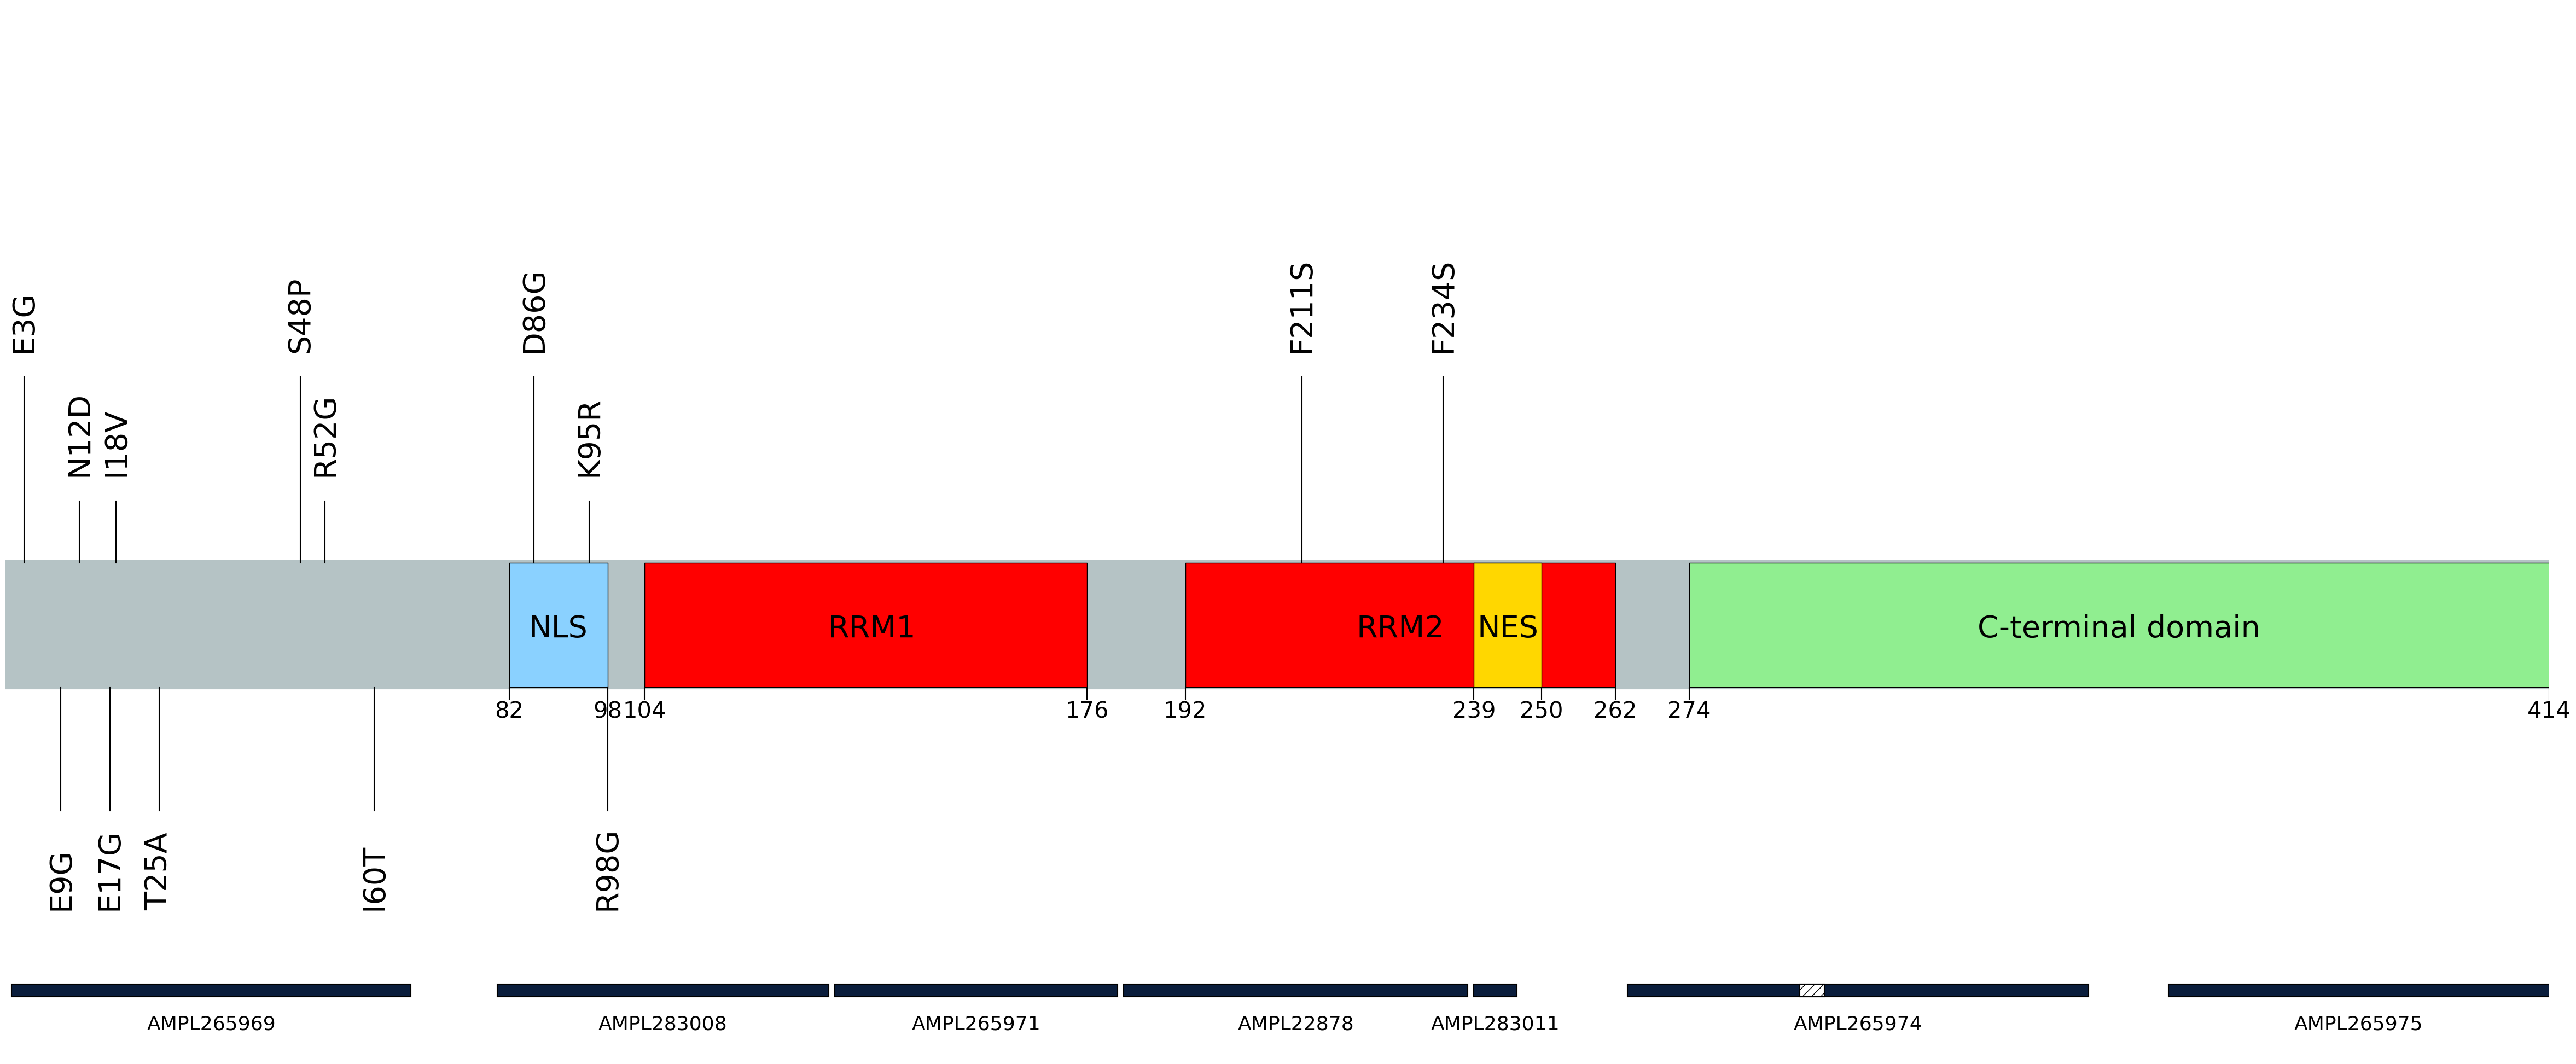

In [32]:
fig, ax = plt.subplots(figsize=(60, 25))
# Main backbone line
ax.plot([1, 414], [0.5, 0.5], color='#B5C3C5', linewidth=170, zorder=1)

# Add rectangles for domains
ax.add_patch(patches.Rectangle((82, 0.4), (98-82), 0.2, edgecolor='black', facecolor='#8AD1FF', zorder=1))  # NLS
ax.add_patch(patches.Rectangle((104, 0.4), (176-104), 0.2, edgecolor='black', facecolor='red', zorder=1))  # RRM1
ax.add_patch(patches.Rectangle((192, 0.4), (262-192), 0.2, edgecolor='black', facecolor='red', zorder=1))  # RRM2
ax.add_patch(patches.Rectangle((239, 0.4), (250-239), 0.2, edgecolor='black', facecolor='gold', zorder=1))  # NES
ax.add_patch(patches.Rectangle((274, 0.4), (414-274), 0.2, edgecolor='black', facecolor='lightgreen', zorder=1))  # C-terminal domain

# Annotations for the rectangles
ax.text(90, 0.48, 'NLS', ha='center', fontsize=40, color='black', zorder=2)
ax.text(141, 0.48, 'RRM1', ha='center', fontsize=40, color='black', zorder=2)
ax.text(227, 0.48, 'RRM2', ha='center', fontsize=40, color='black', zorder=2)
ax.text(244.5, 0.48, 'NES', ha='center', fontsize=40, color='black', zorder=2)
ax.text(344, 0.48, 'C-terminal domain', ha='center', fontsize=40, color='black', zorder=2)

# Add start and end position annotations with lines
positions = [(82, 98), (104, 176), (192, 262), (239, 250), (274, 414)]
for start, end in positions:
    ax.text(start, 0.35, str(start), ha='center', fontsize=30, color='black')
    ax.text(end, 0.35, str(end), ha='center', fontsize=30, color='black')
    ax.plot([start, start], [0.4, 0.38], color='black', linewidth=1.5)
    ax.plot([end, end], [0.4, 0.38], color='black', linewidth=1.5)


position_labels = defaultdict(list)
# Aggregate labels by position 
for _, row in df1.iterrows():
    x_pos = row['Protein_position']
    label = row['am_protein_variant']
    freq = row['cell_count_patients']  
    position_labels[x_pos].append((label, freq))

# Variable to keep track of the last plotted position
last_position = None
toggle_position = True  # Toggle between above and below

# Plot each variant
for x_pos, label_info in sorted(position_labels.items()):
    labels = [info[0] for info in label_info]
    freqs = [info[1] for info in label_info]
    label_text = ", ".join(labels)

    if x_pos in [98]:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 10:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1.5, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    elif x_pos < 192:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 10:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos
    
    elif x_pos == 212:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 5:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            else:
                # Plot above the backbone (default)
                ax.plot([x_pos+1, x_pos+1], [0.6, 0.9], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    elif x_pos == 213:
    # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 5:  
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.35], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1, 0.2, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    elif (x_pos >= 192) & (x_pos < 274):
                # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 5:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    else:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 10:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 1.3], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 1.35, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:

            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 1.1], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 1.15, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

codons_covered = [
    (1, 66),
    (80, 134),
    (135, 181),
    (182, 238),
    (239, 246),
    (264, 339),
    (352, 414),
]

labels = [
    "AMPL265969",
    "AMPL283008",
    "AMPL265971",
    "AMPL22878",
    "AMPL283011",
    "AMPL265974",
    "AMPL265975",
]

# --- Amplicon bars ---
coverage_y = -0.1      
coverage_h = 0.02          
coverage_color = "#0A1D3C" 

for (start, end), label in zip(codons_covered, labels):
    ax.add_patch(
        patches.Rectangle(
            (start, coverage_y),
            (end - start),
            coverage_h,
            edgecolor='black',
            facecolor=coverage_color,
            linewidth=1.5,
            zorder=3
        )
    )

    # label centered under the bar
    center = (start + end) / 2
    ax.text(
        center,
        coverage_y - 0.03,
        label,
        ha='center',
        va='top',
        fontsize=26,
        color='black',
        zorder=4
    )

ax.add_patch(patches.Rectangle(
    (292, coverage_y),
    (296 - 292),
    coverage_h,
    edgecolor='black',
    facecolor='white',
    hatch='//',    
    linewidth=1.5,
    zorder=3))

# Set limits and hide axes
ax.set_xlim(0, 414)
ax.set_ylim(-0.2, 1.5)
ax.axis('off')

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureA.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureA.svg", bbox_inches="tight", transparent=True)
plt.show()


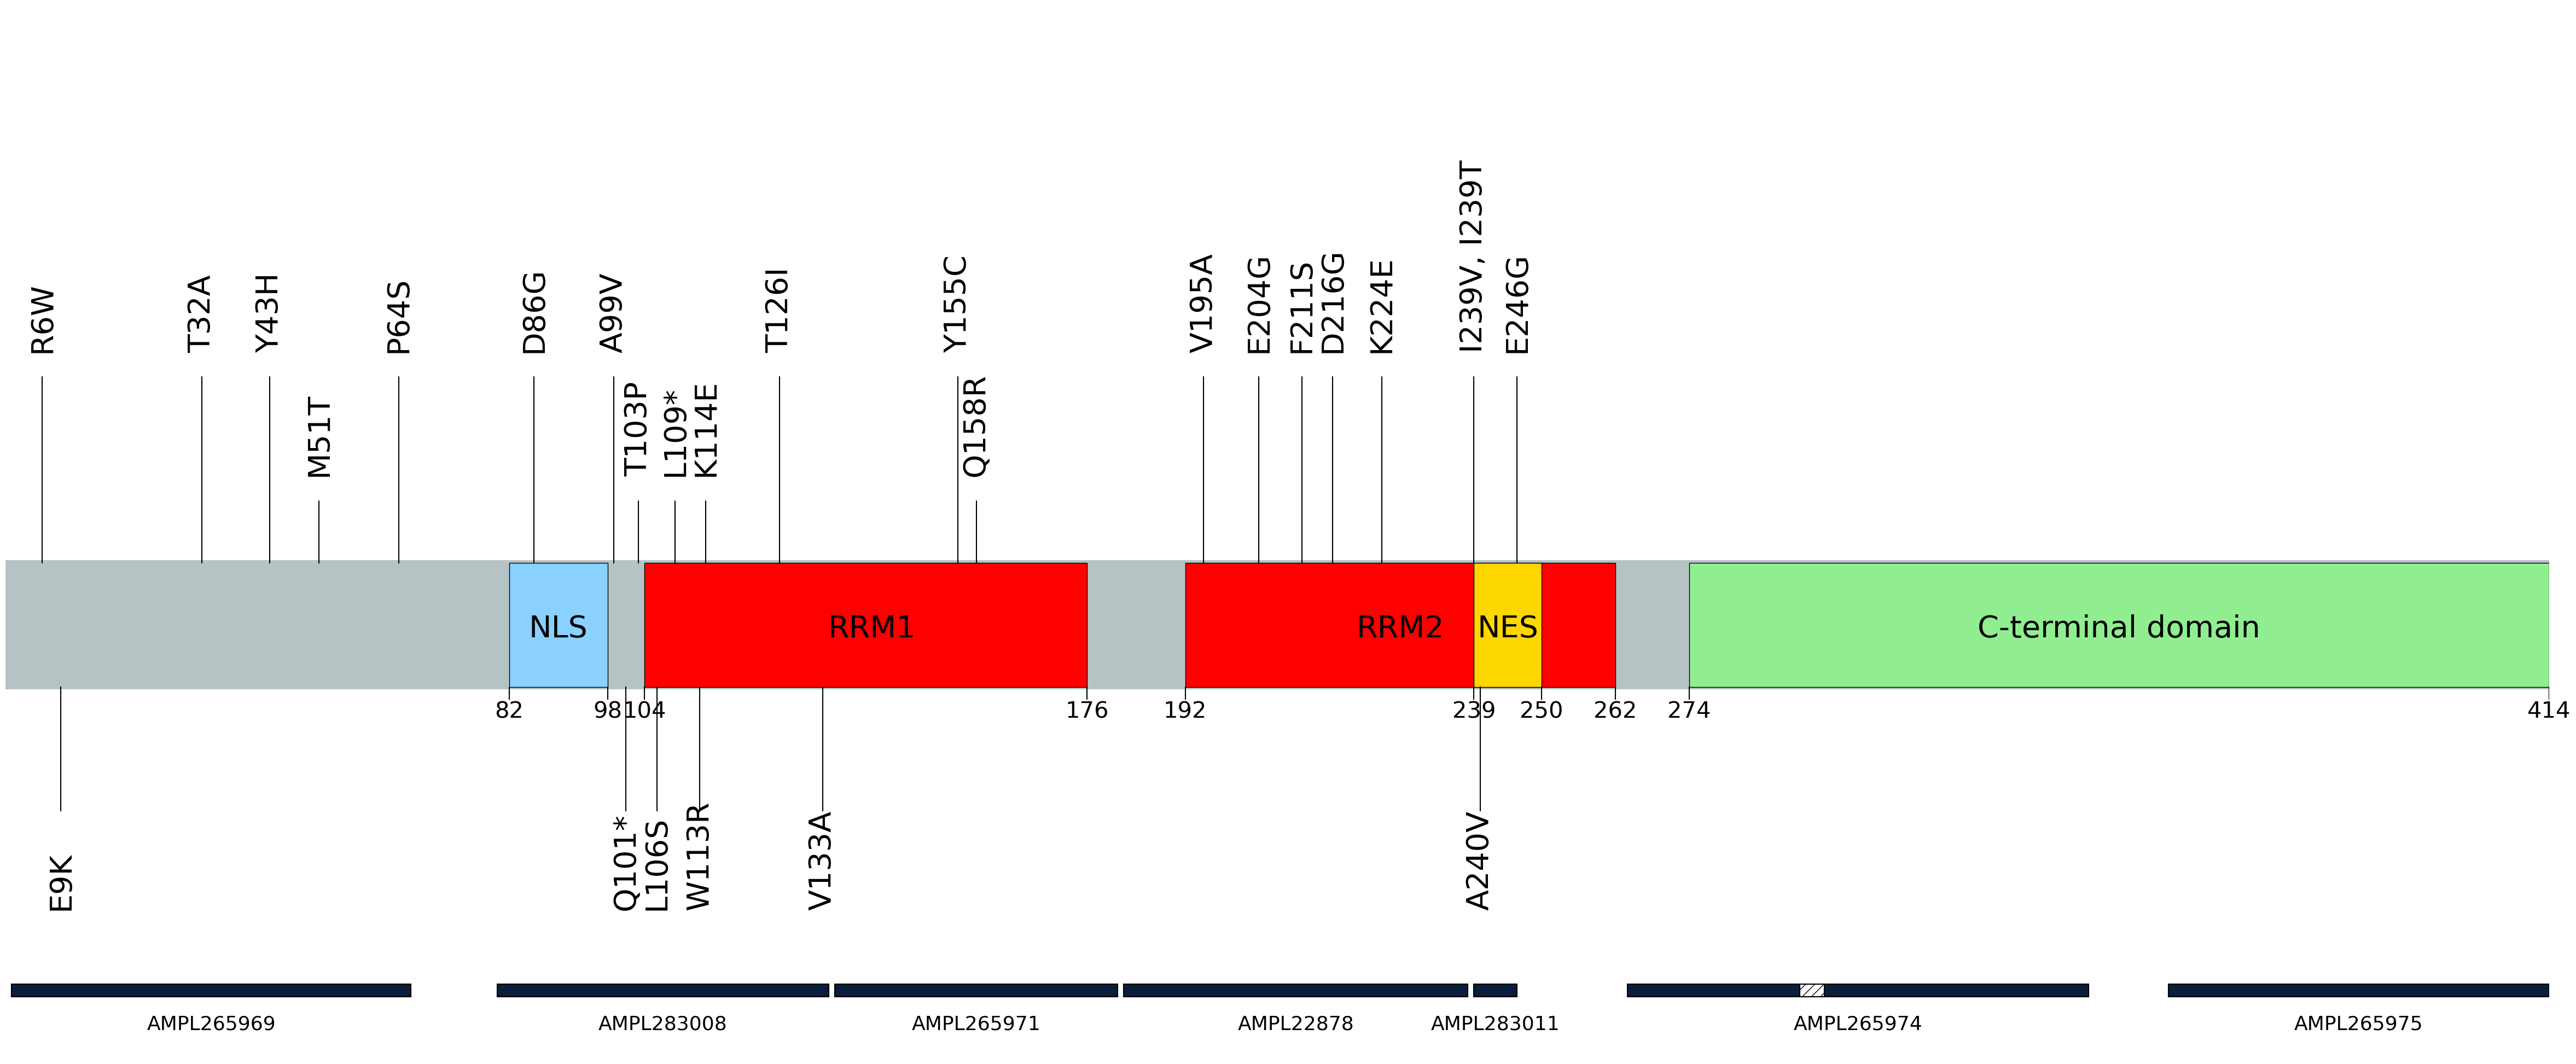

In [33]:
fig, ax = plt.subplots(figsize=(60, 25))
# Main backbone line
ax.plot([1, 414], [0.5, 0.5], color='#B5C3C5', linewidth=170, zorder=1)

# Add rectangles for domains
ax.add_patch(patches.Rectangle((82, 0.4), (98-82), 0.2, edgecolor='black', facecolor='#8AD1FF', zorder=1))  # NLS
ax.add_patch(patches.Rectangle((104, 0.4), (176-104), 0.2, edgecolor='black', facecolor='red', zorder=1))  # RRM1
ax.add_patch(patches.Rectangle((192, 0.4), (262-192), 0.2, edgecolor='black', facecolor='red', zorder=1))  # RRM2
ax.add_patch(patches.Rectangle((239, 0.4), (250-239), 0.2, edgecolor='black', facecolor='gold', zorder=1))  # NES
ax.add_patch(patches.Rectangle((274, 0.4), (414-274), 0.2, edgecolor='black', facecolor='lightgreen', zorder=1))  # C-terminal domain

# Annotations for the rectangles
ax.text(90, 0.48, 'NLS', ha='center', fontsize=40, color='black', zorder=2)
ax.text(141, 0.48, 'RRM1', ha='center', fontsize=40, color='black', zorder=2)
ax.text(227, 0.48, 'RRM2', ha='center', fontsize=40, color='black', zorder=2)
ax.text(244.5, 0.48, 'NES', ha='center', fontsize=40, color='black', zorder=2)
ax.text(344, 0.48, 'C-terminal domain', ha='center', fontsize=40, color='black', zorder=2)

# Add start and end position annotations with lines
positions = [(82, 98), (104, 176), (192, 262), (239, 250), (274, 414)]
for start, end in positions:
    ax.text(start, 0.35, str(start), ha='center', fontsize=30, color='black')
    ax.text(end, 0.35, str(end), ha='center', fontsize=30, color='black')
    ax.plot([start, start], [0.4, 0.38], color='black', linewidth=1.5)
    ax.plot([end, end], [0.4, 0.38], color='black', linewidth=1.5)


position_labels = defaultdict(list)
# Aggregate labels by position 
for _, row in df2.iterrows():
    x_pos = row['Protein_position']
    label = row['am_protein_variant']
    freq = row['cell_count_patients']  
    position_labels[x_pos].append((label, freq))


# Variable to keep track of the last plotted position
last_position = None
toggle_position = True  # Toggle between above and below

# Plot each variant
for x_pos, label_info in sorted(position_labels.items()):
    labels = [info[0] for info in label_info]
    freqs = [info[1] for info in label_info]
    label_text = ", ".join(labels)

    if x_pos in [98]:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 10:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1.5, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    elif x_pos < 192:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 10:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos
    
    elif x_pos == 212:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 5:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            else:
                # Plot above the backbone (default)
                ax.plot([x_pos+1, x_pos+1], [0.6, 0.9], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    elif x_pos == 213:
    # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 5:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.35], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1, 0.2, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos+1, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    elif (x_pos >= 192) & (x_pos < 274):
                # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 5:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 0.7], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.75, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:
            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 0.9], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 0.95, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

    else:
        # Determine whether to plot above or below based on proximity to last position
        if last_position is not None and abs(x_pos - last_position) < 10:  # threshold = 10
            if toggle_position:
                # Plot below the backbone
                ax.plot([x_pos, x_pos], [0.4, 0.2], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 0.05, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            

            else:
                # Plot above the backbone (default)
                ax.plot([x_pos, x_pos], [0.6, 1.3], color='black', linestyle='-', zorder=2)
                ax.text(x_pos, 1.35, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
            
            # Alternate the toggle position
            toggle_position = not toggle_position

        else:

            # Plot above the backbone (default)
            ax.plot([x_pos, x_pos], [0.6, 1.1], color='black', linestyle='-', zorder=2)
            ax.text(x_pos, 1.15, label_text, ha='center', fontsize=40, color="black", zorder=2, rotation=90)
        
        # Update last_position
        last_position = x_pos

codons_covered = [
    (1, 66),
    (80, 134),
    (135, 181),
    (182, 238),
    (239, 246),
    (264, 339),
    (352, 414),
]

labels = [
    "AMPL265969",
    "AMPL283008",
    "AMPL265971",
    "AMPL22878",
    "AMPL283011",
    "AMPL265974",
    "AMPL265975",
]

# --- Amplicon bars ---
coverage_y = -0.1      
coverage_h = 0.02      
coverage_color = "#0A1D3C" 

for (start, end), label in zip(codons_covered, labels):
    # rectangle spanning [start, end]
    ax.add_patch(
        patches.Rectangle(
            (start, coverage_y),
            (end - start),
            coverage_h,
            edgecolor='black',
            facecolor=coverage_color,
            linewidth=1.5,
            zorder=3
        )
    )

    # label centered under the bar
    center = (start + end) / 2
    ax.text(
        center,
        coverage_y - 0.03,
        label,
        ha='center',
        va='top',
        fontsize=26,
        color='black',
        zorder=4
    )

ax.add_patch(patches.Rectangle(
    (292, coverage_y),
    (296 - 292),
    coverage_h,
    edgecolor='black',
    facecolor='white',
    hatch='//',    
    linewidth=1.5,
    zorder=3))

# Set limits and hide axes
ax.set_xlim(0, 414)
ax.set_ylim(-0.2, 1.5)
ax.axis('off')

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureB.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureB.svg", bbox_inches="tight", transparent=True)
plt.show()


### Circular Plot

In [34]:
# Patient overrepresented variants (Criterion 1)
tardbp_ngt = NGT_list_filtered[0]
data_entries = []
dfs_criterion1 = []
for variant in vars_ovrerep_patients_sel:
    protein_change = non_syn_vars[non_syn_vars.index==variant]['am_protein_variant'].values[0]
    for sample_name in sample_ids:
        NGT_sample = tardbp_ngt[tardbp_ngt['sample_id']== sample_name]  
        condition = NGT_sample['sample_type'].unique()[0]    
        sample_id = NGT_sample['sample_id'].unique()[0]
        identifier = NGT_sample['sample_identifier'].unique()[0]
        sample_type = NGT_sample['sample_type'].unique()[0]

        NGT_sample = NGT_sample[variant]
        res = NGT_sample.isin([1,2]).sum()
        n_cells = NGT_sample.shape[0]
        freq = round((res/n_cells)*100,2)
        if freq > 0:
            #print(f"{sample_id}, {protein_change}, {condition} , {res}, {n_cells}, {freq}")
            row_df = pd.DataFrame({'variant' : [variant], 'protein_change':[protein_change], 'sample': [sample_id], 'identifier':[identifier], 'sample_type': [sample_type], 'freq': [freq], 'n_cells':n_cells, 'mutated_cells':res })
            data_entries.append(row_df)
dfs_criterion1 = pd.concat(data_entries, ignore_index=True)

In [35]:
# Patient exlusive mutations (Criteria 2)
tardbp_ngt = NGT_list_filtered[0]
data_entries = []
dfs_criterion2 = []
for variant in frequent_patients_variants.to_list():
    protein_change = non_syn_vars[non_syn_vars.index==variant]['am_protein_variant'].values[0]
    for sample_name in sample_ids:
        NGT_sample = tardbp_ngt[tardbp_ngt['sample_id']== sample_name]  
        condition = NGT_sample['sample_type'].unique()[0]    
        sample_id = NGT_sample['sample_id'].unique()[0]
        identifier = NGT_sample['sample_identifier'].unique()[0]
        sample_type = NGT_sample['sample_type'].unique()[0]

        NGT_sample = NGT_sample[variant]
        res = NGT_sample.isin([1,2]).sum()
        n_cells = NGT_sample.shape[0]
        freq = round((res/n_cells)*100,2)
        if freq > 0:
            #print(f"{sample_id}, {protein_change}, {condition} , {res}, {n_cells}, {freq}")
            row_df = pd.DataFrame({'variant' : [variant], 'protein_change':[protein_change], 'sample': [sample_id], 'identifier':[identifier], 'sample_type': [sample_type], 'freq': [freq], 'n_cells':n_cells, 'mutated_cells':res })
            data_entries.append(row_df)
dfs_criterion2  = pd.concat(data_entries, ignore_index=True)

In [36]:
dfs_criterion1['protein_change'] = 'p.' + dfs_criterion1['protein_change'].astype(str)
dfs_criterion2['protein_change'] = 'p.' + dfs_criterion2['protein_change'].astype(str)


In [37]:
dfs_selected1 = dfs_criterion1[dfs_criterion1['protein_change'].isin(['p.E9G', 'p.I18V', 'p.E17G'])]
dfs_selected2 = dfs_criterion2[dfs_criterion2['protein_change'].isin(['p.Y43H', 'p.D86G', 'p.F211S'])]


In [38]:
for variant in dfs_selected1['variant'].unique():
    dfs_selected1.loc[dfs_selected1['variant'] == variant, 'codon'] = non_syn_vars.loc[variant, 'Protein_position']

for variant in dfs_selected2['variant'].unique():
    dfs_selected2.loc[dfs_selected2['variant'] == variant, 'codon'] = non_syn_vars.loc[variant, 'Protein_position']


/tmp/ipykernel_379440/875246641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_selected1.loc[dfs_selected1['variant'] == variant, 'codon'] = non_syn_vars.loc[variant, 'Protein_position']
/tmp/ipykernel_379440/875246641.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_selected2.loc[dfs_selected2['variant'] == variant, 'codon'] = non_syn_vars.loc[variant, 'Protein_position']


In [39]:
dfs_selected1.sort_values(by='codon', ascending=True, inplace=True)
dfs_selected2.sort_values(by='codon', ascending=True, inplace=True)


/tmp/ipykernel_379440/2084968557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_selected1.sort_values(by='codon', ascending=True, inplace=True)
/tmp/ipykernel_379440/2084968557.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_selected2.sort_values(by='codon', ascending=True, inplace=True)


In [40]:
# Helper functions for radial plots
def get_label_rotation(angle, offset):
    # Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

def add_labels(angles, values, labels, offset, ax):
    
    # This is the space between the end of the bar and the label
    padding = 0.05
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)
        if value < 10:
            val = value
        else:
            val = 4
        # And finally add the text
        ax.text(
            x=angle, 
            y=val + padding, 
            s=label, 
            ha=alignment, 
            va="center", 
            rotation=rotation, 
            rotation_mode="anchor",
            fontsize=10
        ) 
        

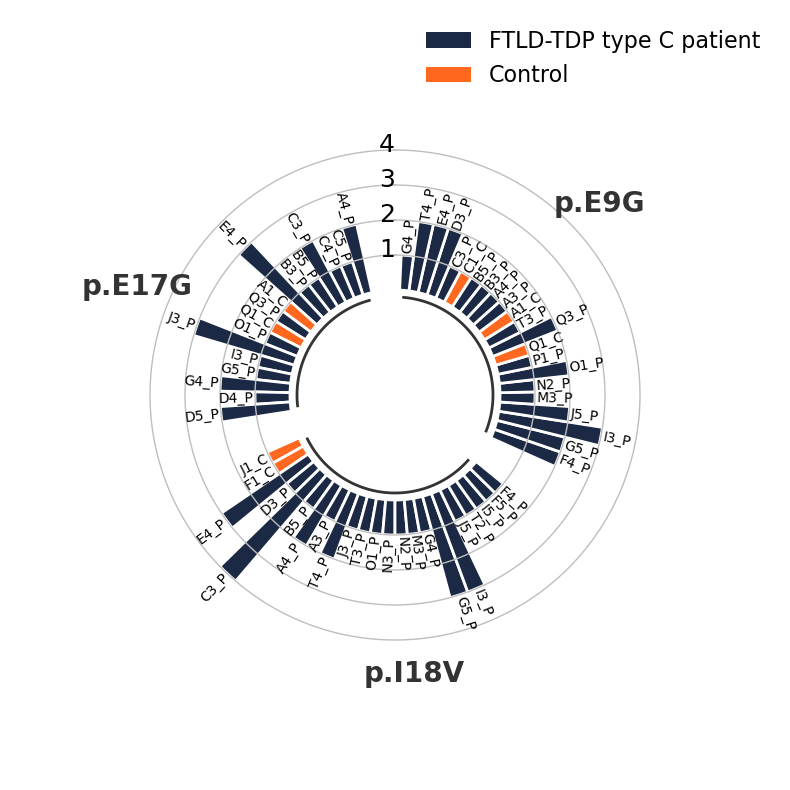

In [41]:
VALUES = dfs_selected1["mutated_cells"].values
LABELS = dfs_selected1["identifier"].values
GROUP = dfs_selected1["protein_change"].values
SCORES = dfs_selected1["sample_type"].values 

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in dfs_selected1.groupby("variant", sort=False)]

OFFSET = np.pi / 2

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD


fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={"projection": "polar"})
ax.set_theta_offset(OFFSET)
ax.set_ylim(-3, 8)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

category_colors = {'P': '#1B2944', 'C': '#FF681E'}  #5A2A82

#category_colors = {'C': "#92C7FF",'P': "#F44542"}

COLORS = [category_colors[group] for group in SCORES] 

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)

add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax)

# Extra customization below here --------------------

offset = 0 
for group, size in zip(list(dict.fromkeys(dfs_selected1['protein_change'])), GROUPS_SIZE):
    # Add line below bars
    x1 = np.linspace(ANGLES[offset + PAD], ANGLES[offset + size + PAD - 1], num=50)
    ax.plot(x1, [-0.2]*50, color="#333333",  lw=2)


    # Add text to indicate group
    ax.text(
        np.mean(x1+0.2), 5, group, color="#333333", fontsize=20, 
        fontweight="bold", ha="center", va="center"
    )
    
    offset += size + PAD
    
for y in [1,2,3,4]:
    ax.plot(np.linspace(0, 2 * np.pi, 500), [y] * 500, color="#bebebe", lw=1)
    ax.text(0, y+ 0.15, f"{y}", color="black", fontsize=18, ha="right", va="center")

legend_elements = [Patch(facecolor=category_colors['P'], label='FTLD-TDP type C patient'),
                   Patch(facecolor=category_colors['C'], label='Control')]

ax.legend(handles=legend_elements, loc='upper right', fontsize=16, frameon=False)

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureA_RADIAL_blackorange.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureA_RADIAL_blackorange.svg", bbox_inches="tight", transparent=True)

plt.show()

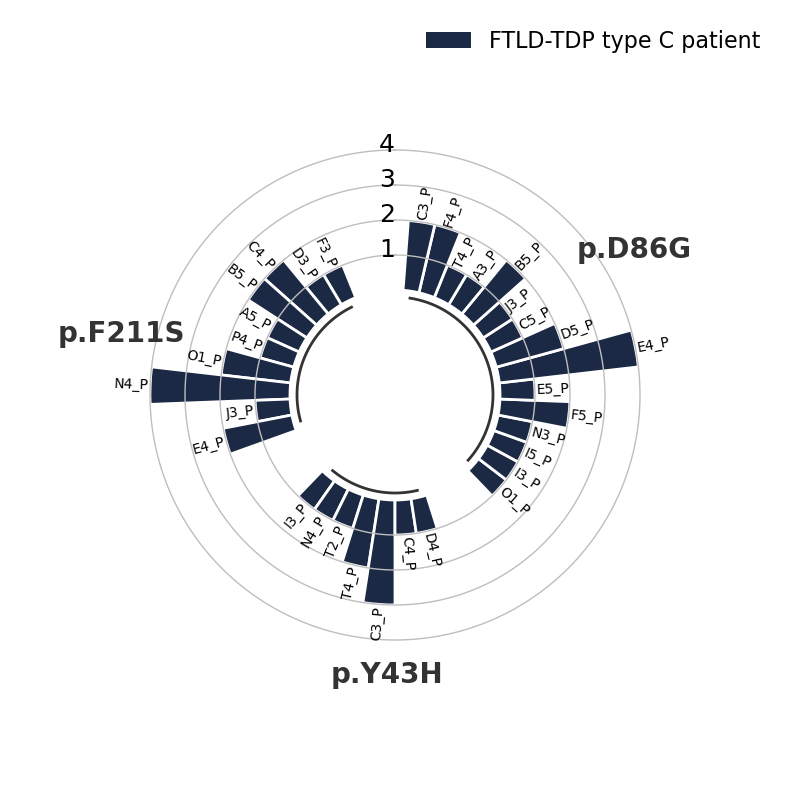

In [42]:
VALUES = dfs_selected2["mutated_cells"].values
LABELS = dfs_selected2["identifier"].values
GROUP = dfs_selected2["protein_change"].values
SCORES = dfs_selected2["sample_type"].values 

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in dfs_selected2.groupby("variant", sort=False)]

OFFSET = np.pi / 2

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD


fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={"projection": "polar"})
ax.set_theta_offset(OFFSET)
ax.set_ylim(-3, 8)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

#category_colors = {'C': "#92C7FF",'P': "#F44542"}

COLORS = [category_colors[group] for group in SCORES] 

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)

add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax)


offset = 0 
for group, size in zip(list(dict.fromkeys(dfs_selected2['protein_change'])), GROUPS_SIZE):
    # Add line below bars
    x1 = np.linspace(ANGLES[offset + PAD], ANGLES[offset + size + PAD - 1], num=50)
    ax.plot(x1, [-0.2]*50, color="#333333",  lw=2)

    ax.text(
        np.mean(x1+0.2), 5, group, color="#333333", fontsize=20, 
        fontweight="bold", ha="center", va="center"
    )
    
    offset += size + PAD
    
for y in [1,2,3,4]:
    ax.plot(np.linspace(0, 2 * np.pi, 500), [y] * 500, color="#bebebe", lw=1)
    ax.text(0, y+ 0.15, f"{y}", color="black", fontsize=18, ha="right", va="center")

legend_elements = [Patch(facecolor=category_colors['P'], label='FTLD-TDP type C patient')]

ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=16)

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureB_RADIAL_blackorange.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel3/figureB_RADIAL_blackorange.svg", bbox_inches="tight", transparent=True)

plt.show()


#### Extract variants based on similar selection criteria for other genes:

In [43]:
genes = ["TARDBP", "TET2", "TMEM106B", "OPTN", "TBK1", "GRN", "UNC13A"]
indices = {gene: i for i, gene in enumerate(genes)}

In [44]:
overep_vars_list = {}
for gene in genes:
    samples_with_overrep_vars = []
    samples_with_no_overrep_vars = []
    entries = []
    print(f"Gene: {gene}")
    non_syn_vars = var_groups_dict[gene]['Non_synonymous'].copy()
    NGT= NGT_list_filtered[indices[gene]]

    #Run for each sample 
    sample_ids = NGT['sample_id'].unique().tolist()
    for sample_name in sample_ids:
        NGT_sample = NGT[NGT['sample_id'] == (sample_name)]
        
        non_syn_vars["protein_change"] = (
            non_syn_vars["Amino_acids"].str.split("/")
                            .str[0]     
            + non_syn_vars["Protein_position"].astype(str)
            + non_syn_vars["Amino_acids"].str.split("/").str[1]  
        )

        NGT_sample = NGT_sample[non_syn_vars.index.tolist() + NGT_sample.columns[-6:].tolist()] # select the nonysn variants + sample info columns
        #count = pd.DataFrame(NGT_sample.iloc[:, :-6].isin([1,2]).sum()) #count the number of cells carrying each variant
        count = NGT_sample.iloc[:, :-6].isin([1, 2]).sum()
        total = NGT_sample.iloc[:, :-6].isin([0, 1, 2]).sum()
        freq = count / total

        df = pd.DataFrame({
            'n_cells_mutated': count,
            'total_genotyped': total,
            'freq': freq
        })
        # Select variants from a sample with n_cell_mutatated atleast 2 OR with a #cells affected >= 1%
        sel_df = df[(df['n_cells_mutated'] >= 2) | (df["freq"] >= 1)]

        # If there are variants which have a freq >= 1% or are present in >=3 cells ; then
        if sel_df.shape[0] > 0:
            sample_id = NGT_sample['sample_id'].unique()[0]  
            condition = NGT_sample['sample_type'].unique()[0]    
            identifier = NGT_sample['sample_identifier'].unique()[0] 
            samples_with_overrep_vars.append(sample_id)
            row_df = pd.DataFrame({'sample': [sample_id], 'condition':[condition], 'n_cells': [NGT_sample.shape[0]] ,  'variants': [sel_df.index.to_list()], '#_variants': [len(sel_df.index.to_list())], 'Identifier':[identifier]})
            entries.append(row_df)
        else:
            sample_with_no_overep_var = NGT_sample['sample_id'].unique()[0]
            samples_with_no_overrep_vars.append(sample_with_no_overep_var)
        
    variants_selected = pd.concat(entries, ignore_index=True)

    ann = ann_nonsyn_list[indices[gene]].copy()
    ann['Protein_position'] = pd.to_numeric(ann['Protein_position'], errors='coerce')

    df = variants_selected[variants_selected['condition']=="P"]
    df = df.copy()
    df.sort_values(by='#_variants', ascending=True, inplace=True)
    # Count the number of variants and the samples in which they are detected at the given freq/cut-off 
    all_entries = [entry for sublist in df['variants'] for entry in sublist]
    entry_counts = Counter(all_entries)
    counts_df = pd.DataFrame(entry_counts.items(), columns=['SNP', 'Count'])

    df_controls = variants_selected[variants_selected['condition']=="C"]
    df_controls = df_controls.copy()
    df_controls.sort_values(by='#_variants', ascending=True, inplace=True)

    all_entries_controls = [entry for sublist in df_controls['variants'] for entry in sublist]
    entry_counts_controls = Counter(all_entries_controls)
    counts_df_controls = pd.DataFrame(entry_counts_controls.items(), columns=['SNP', 'Count'])

    vars_ovrerep_patients_sel = counts_df[counts_df['Count'] >= 5]['SNP'].to_list()
    controls_overep_list = counts_df_controls['SNP'].to_list()
    vars_sel_overrep_patients = [var for var in vars_ovrerep_patients_sel if var not in controls_overep_list]
    print(f"Non-synonymous variants overrepresented in patients (>=5 samples) : {len(vars_sel_overrep_patients)}")

    x = ann.loc[vars_sel_overrep_patients].copy()
    export_df = x[['am_protein_variant', 'Consequence', 'cell_count_patients', 'total_genotyped_cells_P','cell_count_controls', 'total_genotyped_cells_C', 'am_class', 'am_pathogenicity', 'CADD_PHRED', 'LoF']]

    for var in vars_sel_overrep_patients:
        export_df = export_df.copy()
        barcodes_with_overrepvars = NGT[NGT[var].isin([1,2])==True].index.tolist()
        n_patients = metadata_filtered.loc[barcodes_with_overrepvars][metadata_filtered.loc[barcodes_with_overrepvars]['sample_type']=="P"]['ID'].nunique()
        n_controls = metadata_filtered.loc[barcodes_with_overrepvars][metadata_filtered.loc[barcodes_with_overrepvars]['sample_type']=="C"]['ID'].nunique()
        export_df.loc[var, 'total_patients_affected'] = n_patients
        export_df.loc[var, 'total_controls_affected'] = n_controls
    
    overep_vars_list[gene] = export_df



Gene: TARDBP
Non-synonymous variants overrepresented in patients (>=5 samples) : 14
Gene: TET2
Non-synonymous variants overrepresented in patients (>=5 samples) : 5
Gene: TMEM106B
Non-synonymous variants overrepresented in patients (>=5 samples) : 3
Gene: OPTN
Non-synonymous variants overrepresented in patients (>=5 samples) : 7
Gene: TBK1
Non-synonymous variants overrepresented in patients (>=5 samples) : 7
Gene: GRN
Non-synonymous variants overrepresented in patients (>=5 samples) : 0
Gene: UNC13A
Non-synonymous variants overrepresented in patients (>=5 samples) : 30


Select variants which are exclusively found in patients

In [45]:
patient_only_vars = {}
for gene in genes:
    patient_exclusive_vars = []
    print(f"Gene: {gene}")
    non_syn_vars = var_groups_dict[gene]['Non_synonymous'].copy()
    NGT= NGT_list_filtered[indices[gene]]
    
    patient_exclusive = non_syn_vars[non_syn_vars['mutation_freq_C']==0]
    frequent_patients_variants = patient_exclusive[patient_exclusive['cell_count_patients'] >= 10].index
    print(f"Non-synonymous variants exclusive to patients (>=10 cells) : {len(frequent_patients_variants)}")
    y = non_syn_vars.loc[frequent_patients_variants]
    export_df_patients = y[['am_protein_variant', 'Consequence', 'cell_count_patients', 'total_genotyped_cells_P','cell_count_controls', 'total_genotyped_cells_C', 'am_class', 'am_pathogenicity', 'CADD_PHRED', 'LoF']].copy()
    for var in frequent_patients_variants:
        export_df_patients = export_df_patients.copy()
        barcodes_with_patientexcl = NGT[NGT[var].isin([1,2])==True].index.tolist()
        n_patients = metadata_filtered.loc[barcodes_with_patientexcl][metadata_filtered.loc[barcodes_with_patientexcl]['sample_type']=="P"]['ID'].nunique()
        n_controls = metadata_filtered.loc[barcodes_with_patientexcl][metadata_filtered.loc[barcodes_with_patientexcl]['sample_type']=="C"]['ID'].nunique()
        export_df_patients.loc[var, 'total_patients_affected'] = n_patients
        export_df_patients.loc[var, 'total_controls_affected'] = n_controls
    patient_only_vars[gene] = export_df_patients

Gene: TARDBP
Non-synonymous variants exclusive to patients (>=10 cells) : 27
Gene: TET2
Non-synonymous variants exclusive to patients (>=10 cells) : 51
Gene: TMEM106B
Non-synonymous variants exclusive to patients (>=10 cells) : 17
Gene: OPTN
Non-synonymous variants exclusive to patients (>=10 cells) : 38
Gene: TBK1
Non-synonymous variants exclusive to patients (>=10 cells) : 47
Gene: GRN
Non-synonymous variants exclusive to patients (>=10 cells) : 17
Gene: UNC13A
Non-synonymous variants exclusive to patients (>=10 cells) : 113
